In [1]:
!pip install lime shap torchcam opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of torchcam to determine which version is compatible with other requirements. This could take a while.
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=2acb614b72f04752ceef72df263a14e898ac313d8f08ff89fab4919c1b15bddc
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [4]:

MODEL_PATH = "/content/drive/MyDrive/mobilenet_pneumonia.pth"
IMAGE_FOLDER = "/content/drive/MyDrive/CHEST X-RAY IMAGES/chest_xray/test"

In [5]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models

import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

from PIL import Image

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [7]:
model = models.mobilenet_v2(pretrained=False)

model.classifier[1] = nn.Linear(model.last_channel, 2)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model = model.to(device)
model.eval()

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

In [8]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

In [9]:
classes = ["Normal", "Pneumonia"]

In [10]:
def predict_image(image_path):

    image = Image.open(image_path).convert("RGB")

    img = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img)

        probs = torch.softmax(output, dim=1)

        conf, pred = torch.max(probs,1)

    label = classes[pred.item()]
    confidence = conf.item()*100

    return label, confidence

In [12]:
for class_folder in os.listdir(IMAGE_FOLDER):

    class_path = os.path.join(IMAGE_FOLDER, class_folder)

    # check if folder
    if os.path.isdir(class_path):

        for img_name in os.listdir(class_path):

            img_path = os.path.join(class_path, img_name)

            label, conf = predict_image(img_path)

            print(f"Image: {img_name}")
            print(f"Actual Class: {class_folder}")
            print(f"Predicted: {label}")
            print(f"Confidence: {conf:.2f}%")
            print("--------------------")

Image: IM-0019-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 98.96%
--------------------
Image: IM-0015-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 95.86%
--------------------
Image: IM-0001-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 91.78%
--------------------
Image: IM-0017-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 94.34%
--------------------
Image: IM-0022-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 100.00%
--------------------
Image: IM-0006-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 95.65%
--------------------
Image: IM-0010-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 76.62%
--------------------
Image: IM-0013-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 96.91%
--------------------
Image: IM-0011-0001-0001.jpeg
Actual Class: NORMAL
Predicted: Pneumonia
Confidence: 96.53%
--------------------
Image: IM-0003-0001.jpeg
Actual

In [13]:
from torchcam.methods import GradCAM
from torchvision.transforms.functional import to_pil_image

cam_extractor = GradCAM(model, target_layer="features.18")

In [39]:
from torchcam.methods import GradCAM
import cv2

cam_extractor = GradCAM(model, target_layer="features.18")

def show_gradcam(image_path):

    image = Image.open(image_path).convert("RGB")

    img = transform(image).unsqueeze(0).to(device)

    img.requires_grad_()   # IMPORTANT FIX

    output = model(img)

    pred = output.argmax(dim=1).item()

    activation_map = cam_extractor(pred, output)[0].cpu()

    img_np = np.array(image.resize((224,224)))

    heatmap = cv2.resize(activation_map.numpy(), (224,224))
    heatmap = np.uint8(255 * heatmap)

    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + img_np

    plt.figure(figsize=(6,6))
    plt.imshow(superimposed.astype("uint8"))
    plt.title("GradCAM Explanation")
    plt.axis("off")
    plt.show()

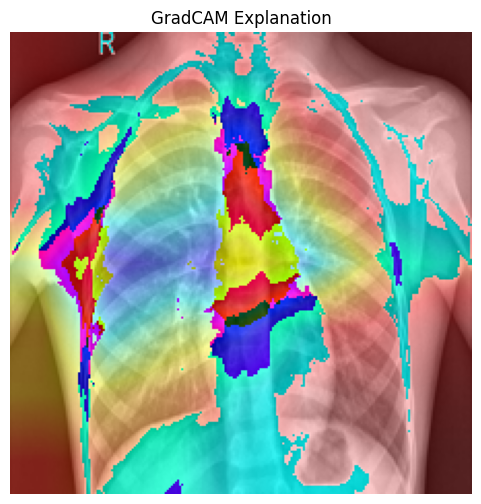

In [40]:
show_gradcam("/content/drive/MyDrive/CHEST X-RAY IMAGES/chest_xray/test/NORMAL/IM-0001-0001.jpeg")

In [16]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

In [20]:
def batch_predict(images):

    model.eval()

    batch = torch.stack([
        transform(Image.fromarray(img))
        for img in images
    ]).to(device)

    batch.requires_grad = True   # important for LIME

    outputs = model(batch)

    probs = torch.softmax(outputs, dim=1)

    return probs.detach().cpu().numpy()

In [21]:
from lime import lime_image
from skimage.segmentation import mark_boundaries

def show_lime(image_path):

    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        image_np,
        batch_predict,
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    plt.figure(figsize=(6,6))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title("LIME Explanation")
    plt.axis("off")
    plt.show()

  0%|          | 0/1000 [00:00<?, ?it/s]

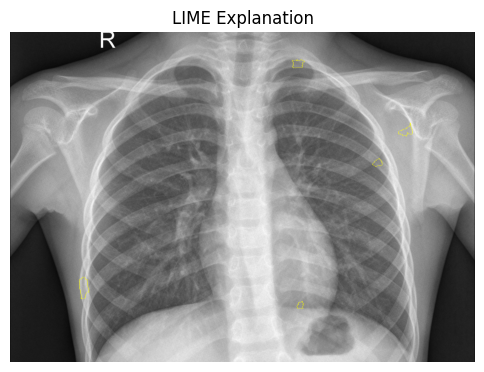

In [22]:
show_lime("/content/drive/MyDrive/CHEST X-RAY IMAGES/chest_xray/test/NORMAL/IM-0001-0001.jpeg")

In [23]:
import shap

In [28]:
background_images = []

normal_folder = "/content/drive/MyDrive/CHEST X-RAY IMAGES/chest_xray/test/NORMAL"

files = os.listdir(normal_folder)[:10]

for f in files:

    img_path = os.path.join(normal_folder, f)

    img = Image.open(img_path).convert("RGB")

    img = transform(img)

    background_images.append(img)

background = torch.stack(background_images).to(device)

In [29]:
import shap

explainer = shap.GradientExplainer(model, background)

In [34]:
def show_shap(image_path):

    image = Image.open(image_path).convert("RGB")

    img = transform(image).unsqueeze(0).to(device)

    shap_values = explainer.shap_values(img)

    # Convert original image to numpy
    img_np = np.array(image.resize((224,224)))

    # Add batch dimension (important)
    img_np = np.expand_dims(img_np, axis=0)

    # Convert SHAP output (C,H,W) -> (H,W,C)
    shap_val = np.transpose(shap_values[0][0], (1,2,0))

    # Add batch dimension
    shap_val = np.expand_dims(shap_val, axis=0)

    shap.image_plot(shap_val, img_np)

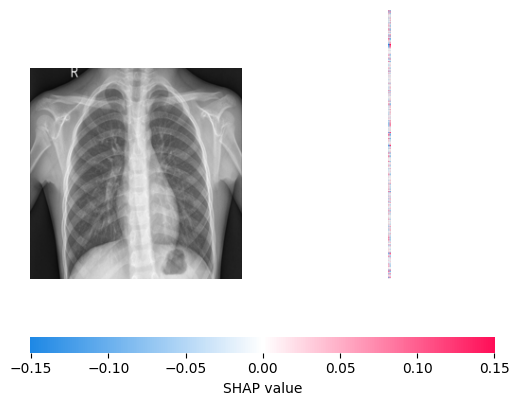

In [35]:
show_shap("/content/drive/MyDrive/CHEST X-RAY IMAGES/chest_xray/test/NORMAL/IM-0001-0001.jpeg")

In [41]:
def analyze_image(image_path):

    label, conf = predict_image(image_path)

    print("Prediction:", label)
    print(f"Confidence: {conf:.2f}%")

    print("Generating GradCAM...")
    show_gradcam(image_path)

    print("Generating LIME...")
    show_lime(image_path)

    print("Generating SHAP...")
    show_shap(image_path)

In [42]:
analyze_image("/content/drive/MyDrive/CHEST X-RAY IMAGES/chest_xray/test/NORMAL/IM-0001-0001.jpeg")